# Warmup PCA

In this warmup we will get familiar with **Principal Component Analysis (PCA)** using the classic `digits` dataset from `sklearn`. PCA is an unsupervised learning technique used to reduce the dimensionality of a dataset while preserving as much variance as possible.

Objectives:
- Load the digits dataset
- Standardize the features
- Fit a PCA and explore the explained variance
- Project the data into a 2D space and visualize it
- Reconstruct images from a reduced number of components

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## 1. Load the dataset

The digits dataset contains 1797 images of handwritten digits (8x8 pixels) labeled from 0 to 9.

In [2]:
digits = load_digits()
X = digits.data
y = digits.target

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

Shape of X: (1797, 64)
Shape of y: (1797,)
Number of classes: 10


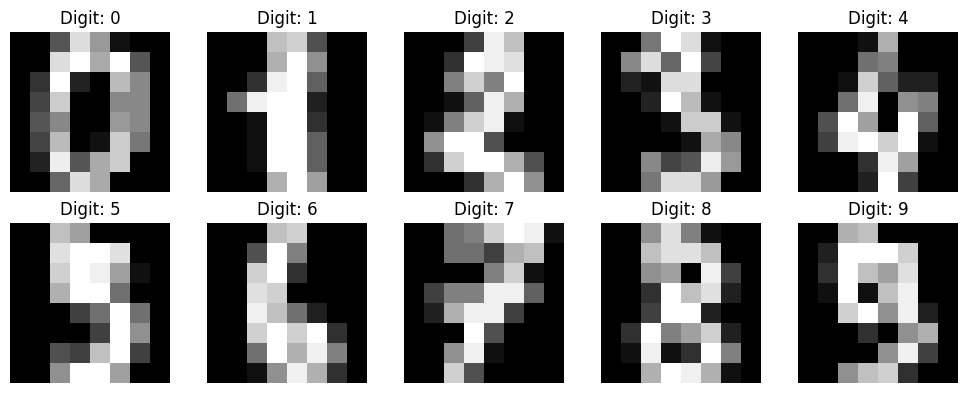

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Digit: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Standardize the features

PCA is sensitive to the scale of the features. We standardize the data so each feature has a mean of 0 and a standard deviation of 1.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Mean of scaled X: {X_scaled.mean():.4f}")
print(f"Std of scaled X: {X_scaled.std():.4f}")

Mean of scaled X: 0.0000
Std of scaled X: 0.9763


## 3. Fit PCA and explore explained variance

Fit PCA on all the components to see how much variance each principal component explains.

In [5]:
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Number of components: {len(explained_variance)}")
print(f"Variance explained by first 10 components: {cumulative_variance[9]:.4f}")
print(f"Components needed to explain 95% variance: {np.argmax(cumulative_variance >= 0.95) + 1}")

Number of components: 64
Variance explained by first 10 components: 0.5887
Components needed to explain 95% variance: 40


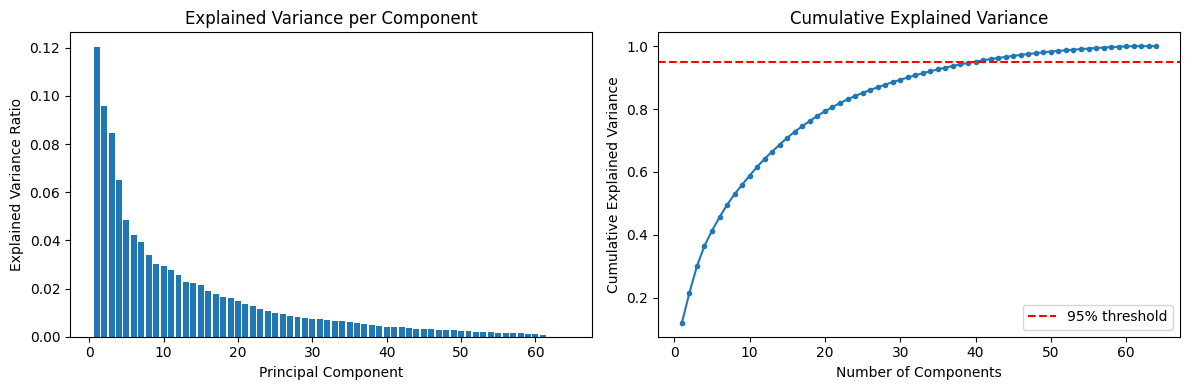

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(explained_variance) + 1), explained_variance)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Explained Variance per Component')

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', markersize=3)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. 2D projection

Project the dataset onto the first two principal components and visualize the classes.

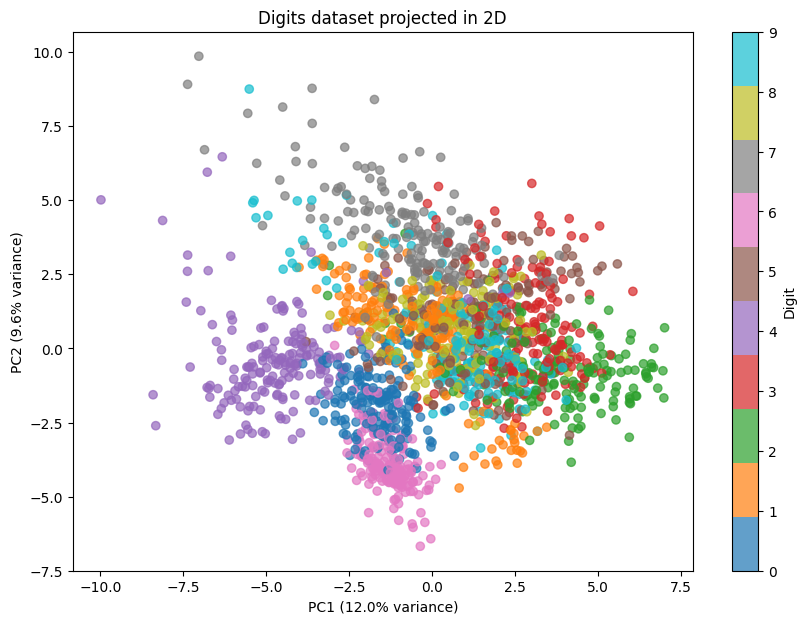

In [7]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Digits dataset projected in 2D')
plt.colorbar(scatter, label='Digit')
plt.show()

## 5. Image reconstruction

One useful property of PCA is that we can *invert* the transformation to reconstruct an approximation of the original data. Let's compare reconstructions using different numbers of components.

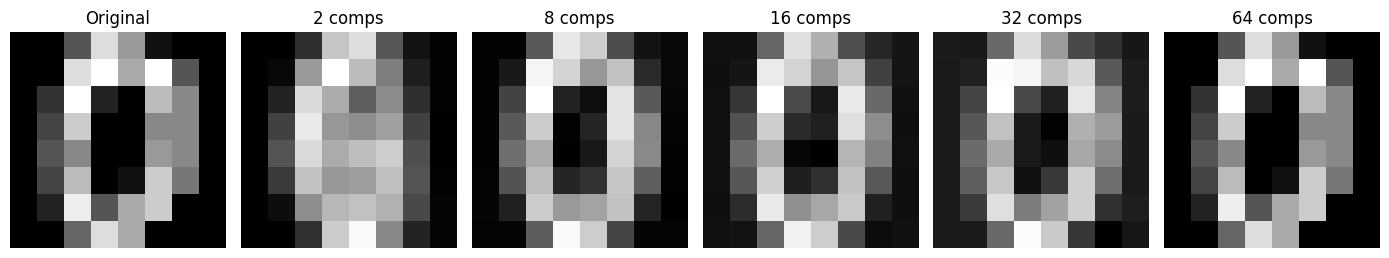

In [8]:
n_components_list = [2, 8, 16, 32, 64]
sample_idx = 0

fig, axes = plt.subplots(1, len(n_components_list) + 1, figsize=(14, 3))
axes[0].imshow(digits.images[sample_idx], cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for i, n in enumerate(n_components_list):
    pca_n = PCA(n_components=n)
    X_proj = pca_n.fit_transform(X_scaled)
    X_reconstructed = pca_n.inverse_transform(X_proj)
    X_reconstructed = scaler.inverse_transform(X_reconstructed)
    
    axes[i + 1].imshow(X_reconstructed[sample_idx].reshape(8, 8), cmap='gray')
    axes[i + 1].set_title(f'{n} comps')
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()

As expected, more components lead to a better reconstruction. With only a few components we already recover the overall shape of the digit, and with 32-64 components the reconstruction is nearly indistinguishable from the original.

We are now ready to apply PCA to a more interesting problem: **face recognition**.